# CPR AD_LTEM demo

This notebook runs pretrained CPR inference, evaluates representative patches, and stitches the complete 12 x 12 AD_LTEM test region.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from datasets import load_ad_ltem_test_set
from utils import (
    AdaptiveImageStitcher,
    average_patch_metrics,
    format_average_metrics,
    format_metrics,
    load_pretrained_model,
    plot_global_stitching,
    plot_patch_comparison,
    reconstruct_patches,
    reconstruction_metrics,
    select_device,
)

In [2]:
ROOT = Path.cwd()
CHECKPOINT = ROOT / 'checkpoints' / 'ad_ltem' / 'best_model.pth'
ASSETS = ROOT / 'assets'

device = select_device()
test_data = load_ad_ltem_test_set(ROOT, grid_size=12)
model = load_pretrained_model(CHECKPOINT, device=device)
amp_pred, phase_pred = reconstruct_patches(
    model, test_data.diffraction, batch_size=64, device=device
)

amp_average = average_patch_metrics(test_data.amplitude, amp_pred)
phase_average = average_patch_metrics(test_data.phase, phase_pred)

print(f'Device: {device}')
print(f'All {len(test_data.diffraction)} AD_LTEM patches (mean ± std)')
print(f'Amplitude: {format_average_metrics(amp_average)}')
print(f'Phase:     {format_average_metrics(phase_average)}')

Device: mps
All 144 AD_LTEM patches (mean ± std)
Amplitude: MSE 0.0424 ± 0.0311 | MAE 0.0471 ± 0.0332 | SSIM 0.826 ± 0.119 | PSNR 16.07 ± 6.72 dB
Phase:     MSE 0.0109 ± 0.0078 | MAE 0.0766 ± 0.0368 | SSIM 0.678 ± 0.102 | PSNR 14.47 ± 3.06 dB


## Patch reconstruction

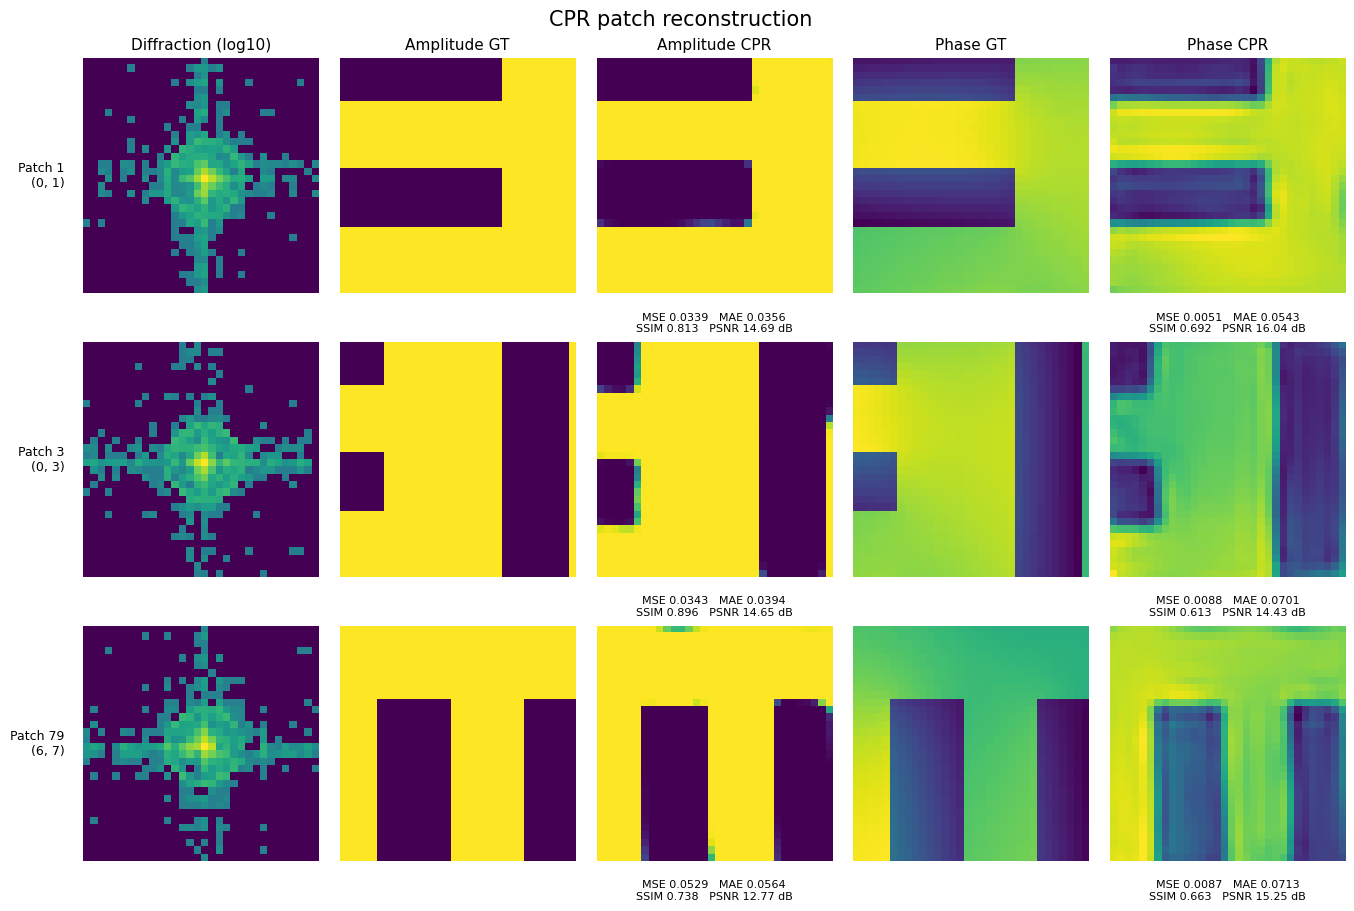

In [3]:
patch_figure, patch_results = plot_patch_comparison(
    test_data.diffraction,
    test_data.amplitude,
    amp_pred,
    test_data.phase,
    phase_pred,
    indices=(1,3,79),
    grid_size=test_data.grid_size,
    save_path=ASSETS / 'patch_comparison.png',
)

plt.show()

## Global stitching

In [4]:
stitcher = AdaptiveImageStitcher(point_size=8, overlap=5 * 8)
global_amp_true = stitcher.stitch(test_data.amplitude, test_data.grid_size)
global_amp_pred = stitcher.stitch(amp_pred, test_data.grid_size)
global_phase_true = stitcher.stitch(test_data.phase, test_data.grid_size)
global_phase_pred = stitcher.stitch(phase_pred, test_data.grid_size)

global_amp_metrics = reconstruction_metrics(global_amp_true, global_amp_pred)
global_phase_metrics = reconstruction_metrics(global_phase_true, global_phase_pred)

print(f'Global shape: {global_amp_true.shape}')
print(f'Amplitude: {format_metrics(global_amp_metrics)}')
print(f'Phase:     {format_metrics(global_phase_metrics)}')

Global shape: (96, 96)
Amplitude: MSE 0.0141   MAE 0.0389 | SSIM 0.815   PSNR 18.52 dB
Phase:     MSE 0.0059   MAE 0.0564 | SSIM 0.811   PSNR 18.62 dB


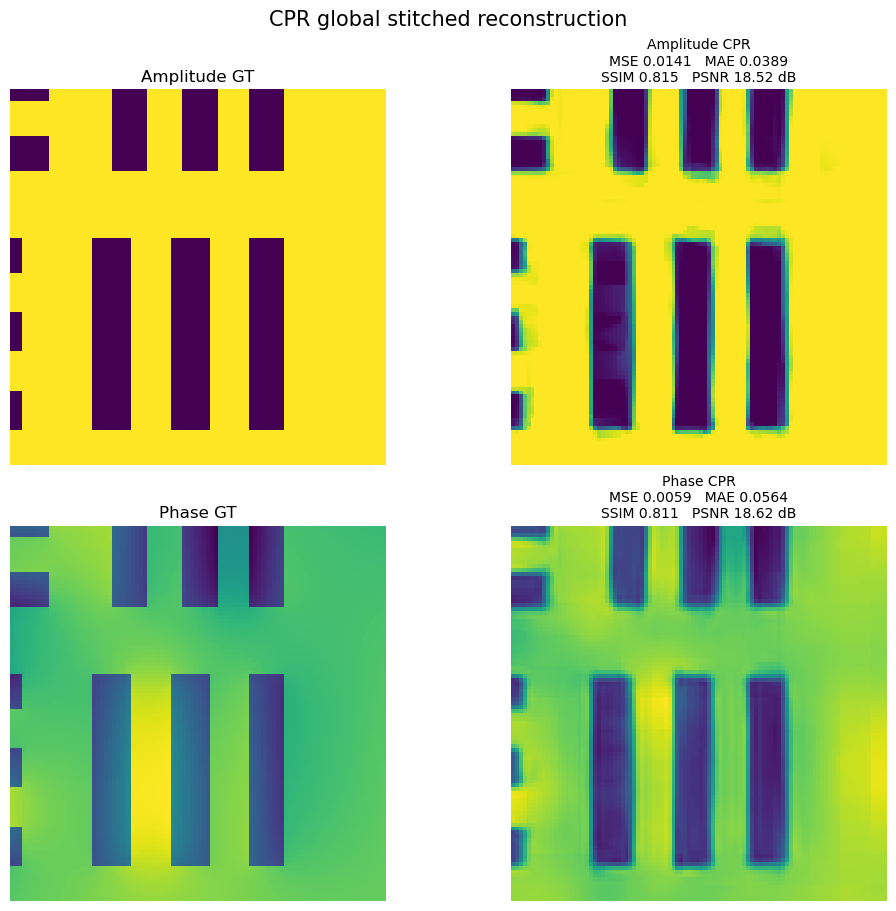

In [5]:
global_figure = plot_global_stitching(
    global_amp_true,
    global_amp_pred,
    global_phase_true,
    global_phase_pred,
    global_amp_metrics,
    global_phase_metrics,
    save_path=ASSETS / 'global_stitching.png',
)
plt.show()